In [1]:
# -----------------------------
# Required Imports
# -----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from plotnine import * 
from plotnine import ggplot, geom_point, facet_grid

In [2]:
# -----------------------------
# Load Datasets
# -----------------------------
variants_data = pd.read_csv("losAlomosData4ML.csv")
variants_data_full = variants_data
#variants_data.head()
stanford_muts = pd.read_csv('data/Stanford-resistance-comments.csv')
stanford_mut_list = set(stanford_muts['Mutation'])
variants_data.shape

# Select only columns that are not in the exclude_cols list
#selected_cols = variants_data.columns.difference(stanford_mut_list)

# Create a new DataFrame with only the selected columns
#variants_data = variants_data[selected_cols]
print(variants_data.shape)

(41247, 8811)


In [3]:
algor_colors = ["#6082B6","#2AAA8A","#E3963E"]

/Users/alfred/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/Users/alfred/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


North America    17764
Asia              8495
Africa            7665
Europe            4232
Others            2650
South America      441
Name: Georegion, dtype: int64
North America    43.067375
Asia             20.595437
Africa           18.583170
Europe           10.260140
Others            6.424710
South America     1.069169
Name: Georegion, dtype: float64


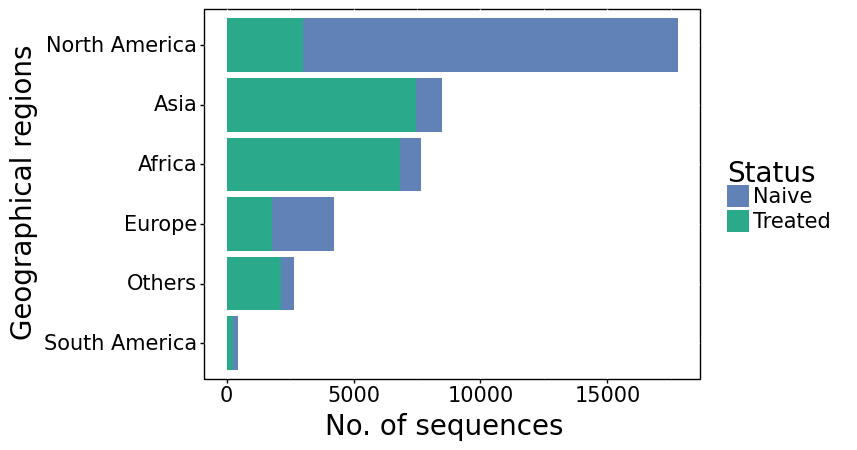

/Users/alfred/miniconda3/lib/python3.7/site-packages/plotnine/ggplot.py:721: PlotnineWarning: Saving 6 x 5 in image.
/Users/alfred/miniconda3/lib/python3.7/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: geog_regions.png


In [19]:
df1 = variants_data[['Georegion','Status']]
# Create a cross-tabulation table with three variables
georegion_map = {'AFR SSA':'Africa', 'Africa':'Africa', 'Asia':'Asia', 'Europe':'Europe',
                  'North America':'North America', 'South America':'South America'}

# Map levels to values and use 'Others' as the default value
df1['Georegion'] = df1['Georegion'].map(georegion_map).fillna('Others')

print(df1['Georegion'].value_counts())
print(df1['Georegion'].value_counts(normalize=True) * 100)


df1['Status'] = df1['Status'].map({'no':'Naive', 'yes':'Treated'}).fillna('Others')

df2 = pd.crosstab([df1['Georegion'], df1['Status']], columns=df1['Status'])

# Reset the index to make the categories columns again
df2.reset_index(inplace=True)

# Convert the table to long form using pd.melt()
df3 = df2.melt(id_vars=['Georegion'], value_vars=['Naive', 'Treated'], var_name='Status', value_name='Count')
df3 = df3[df3['Count']>0]
df3.head()

# Order Georegion by total count
georegion_order = df3.groupby('Georegion')['Count'].sum().sort_values(ascending=True).index
df3['Georegion'] = pd.Categorical(df3['Georegion'], categories=georegion_order, ordered=True)

plotg = ((ggplot(df3)
    + aes(x='Georegion', y='Count', fill='Status')
    + geom_bar(stat="identity")
  #  + facet_wrap('~Algorithm', scales='free') #+ facet_wrap('~Algorithm', scales='free')
    + theme(subplots_adjust={'wspace': 0.15})
    + theme(panel_background=element_rect(fill='white'),
            panel_border=element_rect(color='black',size=1),
            axis_text_x=element_text(color='black', size=15, angle=0),
            axis_text_y=element_text(color='black', size=15),
            axis_title=element_text(color='black', size=20),
            legend_text=element_text(color='black', size=15),
            legend_title=element_text(color='black', size=20),
            strip_text=element_text(color='black',size=20),
            strip_background=element_rect(color='black', fill="white"),
            
      )
    +scale_fill_manual(values = algor_colors)
    +coord_flip()
        +theme(legend_position="right")
    + ylab('No. of sequences')
    + xlab('Geographical regions')))
print(plotg)
plotg.save("geog_regions.png", width=6, height=5, dpi=300)

/Users/alfred/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/Users/alfred/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


ART-experienced    21485
ART-naive          19762
Name: Status, dtype: int64
ART-experienced    52.088637
ART-naive          47.911363
Name: Status, dtype: float64
B           24185
C            5729
CRF01_AE     4356
Others       3851
A1           1088
CRF07_BC      872
D             588
CRF02_AG      578
Name: Subtype, dtype: int64
B           58.634567
C           13.889495
CRF01_AE    10.560768
Others       9.336437
A1           2.637768
CRF07_BC     2.114093
D            1.425558
CRF02_AG     1.401314
Name: Subtype, dtype: float64


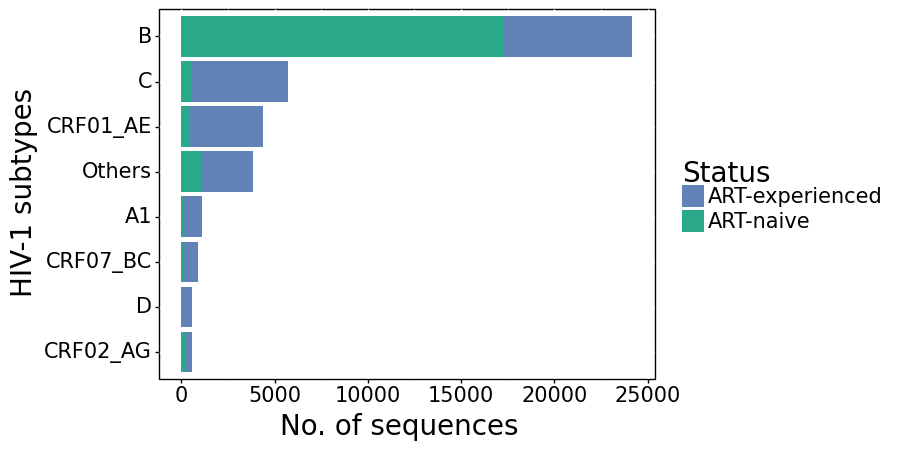

/Users/alfred/miniconda3/lib/python3.7/site-packages/plotnine/ggplot.py:721: PlotnineWarning: Saving 6 x 5 in image.
/Users/alfred/miniconda3/lib/python3.7/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: subtypes.png


In [20]:
df1 = variants_data[['Subtype','Status']]
# Create a cross-tabulation table with three variables

subtype_map = {'A1':'A1', 'B':'B', 'C':'C', 'D':'D', '01_AE':'CRF01_AE', '02_AG':'CRF02_AG',
              '07_BC':'CRF07_BC'}
# Map levels to values and use 'Others' as the default value
df1['Subtype'] = df1['Subtype'].map(subtype_map).fillna('Others')


df1['Status'] = df1['Status'].map({'no':'ART-naive', 'yes':'ART-experienced'}).fillna('Others')

print(df1['Status'].value_counts())
print(df1['Status'].value_counts(normalize=True) * 100)


print("=======================================")
print(df1['Subtype'].value_counts())
print(df1['Subtype'].value_counts(normalize=True) * 100)


df2 = pd.crosstab([df1['Subtype'], df1['Status']], columns=df1['Status'])

# Reset the index to make the categories columns again
df2.reset_index(inplace=True)

# Convert the table to long form using pd.melt()
df3 = df2.melt(id_vars=['Subtype'], value_vars=['ART-naive', 'ART-experienced'], var_name='Status', value_name='Count')
df3 = df3[df3['Count']>0]
df3.head(10)

# First, sum counts by Subtype
subtype_order = df3.groupby('Subtype')['Count'].sum().sort_values(ascending=True).index

# Convert Subtype to ordered categorical based on this order
df3['Subtype'] = pd.Categorical(df3['Subtype'], categories=subtype_order, ordered=True)

plots = ((ggplot(df3)
    + aes(x='Subtype', y='Count', fill='Status')
    + geom_bar(stat="identity")
  #  + facet_wrap('~Algorithm', scales='free') #+ facet_wrap('~Algorithm', scales='free')
    + theme(subplots_adjust={'wspace': 0.15})
    + theme(panel_background=element_rect(fill='white'),
            panel_border=element_rect(color='black',size=1),
            axis_text_x=element_text(color='black', size=15, angle=0),
            axis_text_y=element_text(color='black', size=15),
            axis_title=element_text(color='black', size=20),
            legend_text=element_text(color='black', size=15),
            legend_title=element_text(color='black', size=20),
            strip_text=element_text(color='black',size=20),
            strip_background=element_rect(color='black', fill="white"),
            
      )
    +scale_fill_manual(values = algor_colors)
   +coord_flip()
        +theme(legend_position="right")
    + ylab('No. of sequences')
    + xlab('HIV-1 subtypes')))
print(plots)
plots.save("subtypes.png", width=6, height=5, dpi=300)

/Users/alfred/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


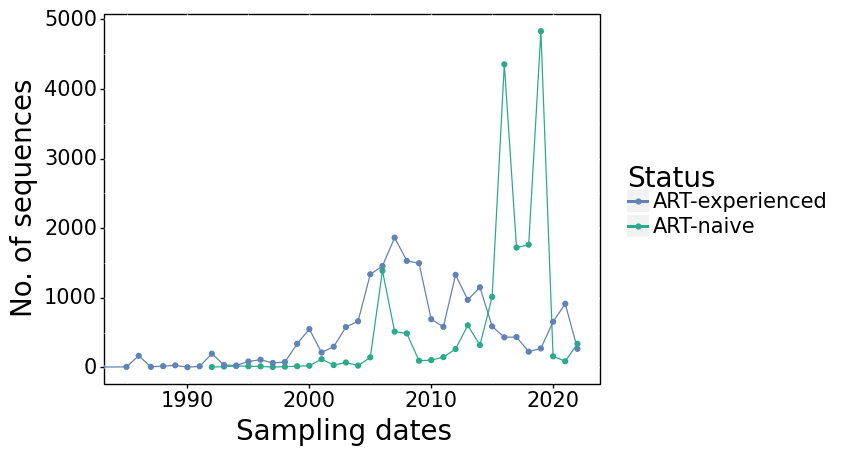

/Users/alfred/miniconda3/lib/python3.7/site-packages/plotnine/ggplot.py:721: PlotnineWarning: Saving 7.5 x 5 in image.
/Users/alfred/miniconda3/lib/python3.7/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: sampling-years.png


In [6]:
df1 = variants_data[['Year','Status']]
# Create a cross-tabulation table with three variables

df1['Status'] = df1['Status'].map({'no':'ART-naive', 'yes':'ART-experienced'}).fillna('Others')

df2 = pd.crosstab([df1['Year'], df1['Status']], columns=df1['Status'])

# Reset the index to make the categories columns again
df2.reset_index(inplace=True)

# Convert the table to long form using pd.melt()
df3 = df2.melt(id_vars=['Year'], value_vars=['ART-naive', 'ART-experienced'], var_name='Status', value_name='Count')
df3 = df3[df3['Count']>0]
df3.head(10)

ploty = ((ggplot(df3)
    + aes(x='Year', y='Count', color='Status')
 #   + geom_bar(stat="identity")
          + geom_line()
          + geom_point()
  #  + facet_wrap('~Algorithm', scales='free') #+ facet_wrap('~Algorithm', scales='free')
    + theme(subplots_adjust={'wspace': 0.15})
    + theme(panel_background=element_rect(fill='white'),
            panel_border=element_rect(color='black',size=1),
            axis_text_x=element_text(color='black', size=15, angle=0),
            axis_text_y=element_text(color='black', size=15),
            axis_title=element_text(color='black', size=20),
            legend_text=element_text(color='black', size=15),
            legend_title=element_text(color='black', size=20),
            strip_text=element_text(color='black',size=20),
            strip_background=element_rect(color='black', fill="white"),
            
      )+coord_cartesian(xlim=(1985, 2022))
    +scale_color_manual(values = algor_colors)
  #  +coord_flip()
        +theme(legend_position="right")
    + ylab('No. of sequences')
    + xlab('Sampling dates')))
print(ploty)
ploty.save("sampling-years.png", width=7.5, height=5, dpi=300)

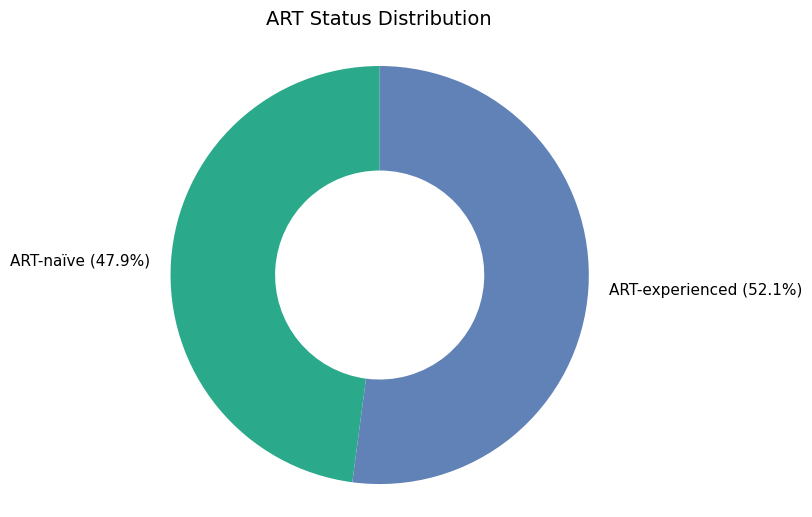

In [7]:
import matplotlib.pyplot as plt

sizes = [19762, 21485]
labels = ['ART-naïve (47.9%)', 'ART-experienced (52.1%)']
colors = ["#2AAA8A","#6082B6"]

fig, ax = plt.subplots(figsize=(6,6))

wedges, texts = ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    startangle=90,
    labeldistance=1.1,           # pushes labels outside
    wedgeprops=dict(width=0.5),  # donut hole size
    textprops=dict(fontsize=11)
)

ax.set_title('ART Status Distribution', fontsize=14, pad=15)
ax.axis('equal')  # keeps circle shape
plt.savefig("ART_status_donut.png", dpi=300, bbox_inches='tight')
plt.show()

In [8]:
stanford_muts_instis = stanford_muts[stanford_muts.Drugclass == 'INSTI'].copy()
stanford_mut_list = stanford_muts_instis['Mutation']
identified_muts = variants_data.columns.intersection(stanford_mut_list)
muts_cols = list(identified_muts) + ['Status']

In [9]:
drms_prevdf = variants_data[muts_cols]
drms_prevdf.shape

(41247, 56)

In [10]:
# List of mutation columns
mutation_cols = drms_prevdf.columns.drop('Status')

# Group by Status and calculate counts and prevalence
counts = drms_prevdf.groupby('Status')[mutation_cols].sum().transpose()
prevalence = drms_prevdf.groupby('Status')[mutation_cols].mean().transpose()

# Combine into tidy long format
prevalence_df = pd.concat([counts, prevalence], axis=1, keys=['count','prevalence'])
prevalence_df = prevalence_df.stack(level=1).reset_index()
prevalence_df.columns = ['Mutation','Status','count','prevalence']

prevalence_df['percentage'] = round(prevalence_df['prevalence']*100,2)

print(prevalence_df.head())

  Mutation Status  count  prevalence  percentage
0    A128T     no     72    0.003643        0.36
1    A128T    yes     57    0.002653        0.27
2     A49G     no     70    0.003542        0.35
3     A49G    yes     10    0.000465        0.05
4    D232N     no    130    0.006578        0.66


In [11]:
mutation_type_map = dict(zip(stanford_muts_instis['Mutation'], stanford_muts_instis['Comment/ Mutation Type']))
#mutation_type_map

In [12]:
# Add mutation type as a new column based on the index
prevalence_df['mutation_type'] = prevalence_df['Mutation'].map(mutation_type_map)

#prevalence_df

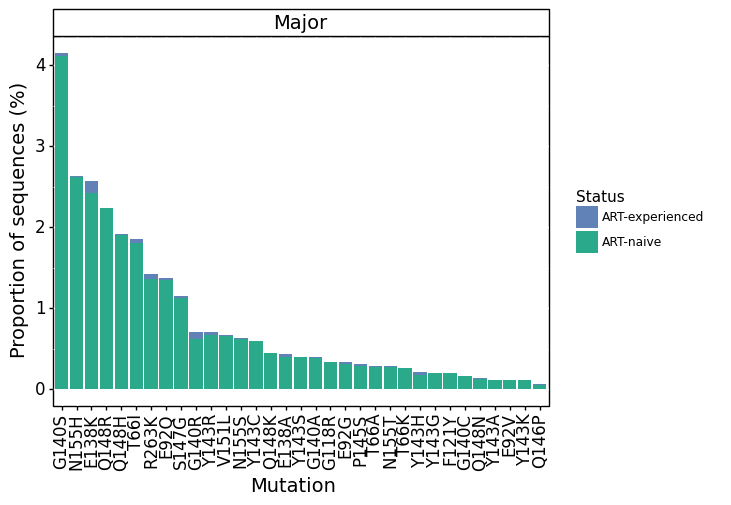

/Users/alfred/miniconda3/lib/python3.7/site-packages/plotnine/ggplot.py:721: PlotnineWarning: Saving 10 x 3 in image.
/Users/alfred/miniconda3/lib/python3.7/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: major-drms.png


In [23]:
from plotnine import *

# Filter for Major only, remove zeros
subset_df = prevalence_df[
    (prevalence_df['mutation_type'] == 'Major') &
    (prevalence_df['count'] > 0)
]

# Sort within each mutation_type by count descending
subset_df = subset_df.sort_values(['mutation_type', 'count'], ascending=[True, False])
subset_df['Status'] = subset_df['Status'].map({'no': 'ART-naive', 'yes': 'ART-experienced'})

mutation_order = subset_df.groupby('Mutation')['count'].sum().sort_values(ascending=False).index
subset_df['Mutation'] = pd.Categorical(subset_df['Mutation'], categories=mutation_order, ordered=True)

# Plot with fill by Status
major_drms = (
    ggplot(subset_df)
    + aes(x='Mutation', y='percentage', fill='Status')
    + geom_bar(stat='identity')
    + facet_wrap('~mutation_type', scales='free')  # independent x-axis per type
  #  + coord_flip()
    + ylab('Proportion of sequences (%)')
    + xlab('Mutation')
    + scale_fill_manual(values=algor_colors)
    + theme(
        panel_background=element_rect(fill='white'),
        panel_border=element_rect(color='black', size=1),
        axis_text_x=element_text(color='black', size=12, angle=90),
        axis_text_y=element_text(color='black', size=12),
        axis_title=element_text(color='black', size=14),
        strip_text=element_text(color='black', size=14),
        strip_background=element_rect(color='black', fill='white'),
        legend_position='right'
    )
)

print(major_drms)
#major_drms.save("major-drms.png", width=4, height=7.5, dpi=300)
major_drms.save("major-drms.png", width=10, height=3, dpi=300)

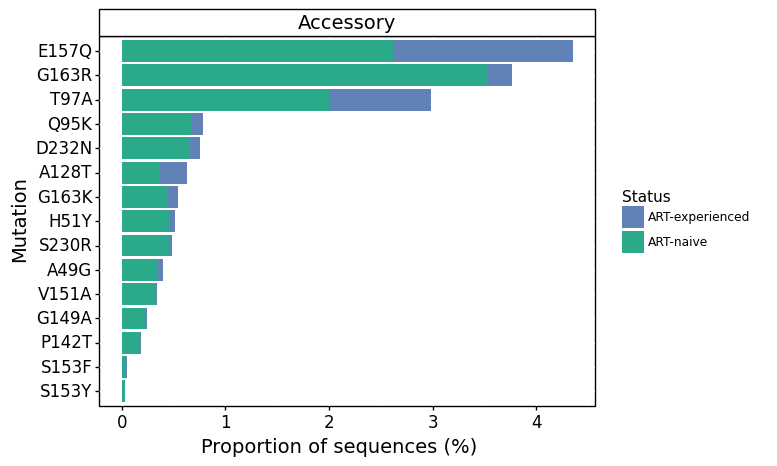

/Users/alfred/miniconda3/lib/python3.7/site-packages/plotnine/ggplot.py:721: PlotnineWarning: Saving 4 x 7.5 in image.
/Users/alfred/miniconda3/lib/python3.7/site-packages/plotnine/ggplot.py:722: PlotnineWarning: Filename: acc-drms.png


In [14]:
from plotnine import *

# Filter for Major only, remove zeros
subset_df = prevalence_df[
    (prevalence_df['mutation_type'] == 'Accessory') &
    (prevalence_df['count'] > 0)
]

# Sort within each mutation_type by count descending
subset_df = subset_df.sort_values(['mutation_type', 'count'], ascending=[True, False])
subset_df['Status'] = subset_df['Status'].map({'no': 'ART-naive', 'yes': 'ART-experienced'})

mutation_order = subset_df.groupby('Mutation')['count'].sum().sort_values(ascending=True).index
subset_df['Mutation'] = pd.Categorical(subset_df['Mutation'], categories=mutation_order, ordered=True)

# Plot with fill by Status
acc_drms = (
    ggplot(subset_df)
    + aes(x='Mutation', y='percentage', fill='Status')
    + geom_bar(stat='identity')
    + facet_wrap('~mutation_type', scales='free')  # independent x-axis per type
    + coord_flip()
    + ylab('Proportion of sequences (%)')
    + xlab('Mutation')
    + scale_fill_manual(values=algor_colors)
    + theme(
        panel_background=element_rect(fill='white'),
        panel_border=element_rect(color='black', size=1),
        axis_text_x=element_text(color='black', size=12),
        axis_text_y=element_text(color='black', size=12),
        axis_title=element_text(color='black', size=14),
        strip_text=element_text(color='black', size=14),
        strip_background=element_rect(color='black', fill='white'),
        legend_position='right'
    )
)

print(acc_drms)
acc_drms.save("acc-drms.png", width=4, height=7.5, dpi=300)